In [1]:
!pip install rdflib networkx matplotlib

   ---------------------------------------- 0.0/615.4 kB ? eta -:--:--
   ---------------------------------------- 615.4/615.4 kB 7.7 MB/s eta 0:00:00


In [2]:
from rdflib import Graph, Literal, RDF, URIRef, Namespace
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
g = Graph()

In [4]:
UNI = Namespace("http://unimib-ds-assistant.org/")

In [5]:
courses = [
    "MachineLearning",
    "DataManagement",
    "DataSemantics"
]

In [6]:
concepts = [
    "Clustering",
    "Classification",
    "Overfitting",
    "RDF",
    "SPARQL",
    "Ontology",
    "KnowledgeGraph",
    "NoSQL",
    "MongoDB",
    "GraphDatabase",
    "Neo4j"
]

In [7]:
relations = [
    ("MachineLearning", "covers", "Clustering"),
    ("MachineLearning", "covers", "Classification"),
    ("MachineLearning", "covers", "Overfitting"),

    ("DataSemantics", "covers", "RDF"),
    ("DataSemantics", "covers", "SPARQL"),
    ("DataSemantics", "covers", "Ontology"),
    ("DataSemantics", "covers", "KnowledgeGraph"),

    ("DataManagement", "covers", "NoSQL"),
    ("DataManagement", "covers", "MongoDB"),
    ("DataManagement", "covers", "GraphDatabase"),

    ("GraphDatabase", "implementedBy", "Neo4j")
]

In [8]:
for subject, predicate, obj in relations:

    g.add((
        UNI[subject],
        UNI[predicate],
        UNI[obj]
    ))

In [9]:
print(f"Total triples: {len(g)}")

Total triples: 11


In [10]:
for s, p, o in g:
    print(s, p, o)

http://unimib-ds-assistant.org/DataManagement http://unimib-ds-assistant.org/covers http://unimib-ds-assistant.org/NoSQL
http://unimib-ds-assistant.org/MachineLearning http://unimib-ds-assistant.org/covers http://unimib-ds-assistant.org/Classification
http://unimib-ds-assistant.org/GraphDatabase http://unimib-ds-assistant.org/implementedBy http://unimib-ds-assistant.org/Neo4j
http://unimib-ds-assistant.org/MachineLearning http://unimib-ds-assistant.org/covers http://unimib-ds-assistant.org/Clustering
http://unimib-ds-assistant.org/DataManagement http://unimib-ds-assistant.org/covers http://unimib-ds-assistant.org/MongoDB
http://unimib-ds-assistant.org/DataSemantics http://unimib-ds-assistant.org/covers http://unimib-ds-assistant.org/RDF
http://unimib-ds-assistant.org/DataSemantics http://unimib-ds-assistant.org/covers http://unimib-ds-assistant.org/KnowledgeGraph
http://unimib-ds-assistant.org/DataSemantics http://unimib-ds-assistant.org/covers http://unimib-ds-assistant.org/Ontology
h

In [11]:
KG_PATH = r"D:\1 Univesrity work\Lect 2\Data semantics\Knowledge-Graph-Enhanced-RAG-System-for-Academic-Question-Answering-in-a-Data-Science-Curriculum\knowledge_graph"

import os
os.makedirs(KG_PATH, exist_ok=True)

In [12]:
g.serialize(
    destination=os.path.join(KG_PATH, "academic_kg.ttl"),
    format="turtle"
)

print("Knowledge Graph saved!")

Knowledge Graph saved!


In [13]:
query_subject = UNI["DataSemantics"]

for s, p, o in g.triples((query_subject, None, None)):
    print(f"{s.split('/')[-1]} --> {p.split('/')[-1]} --> {o.split('/')[-1]}")

DataSemantics --> covers --> RDF
DataSemantics --> covers --> SPARQL
DataSemantics --> covers --> Ontology
DataSemantics --> covers --> KnowledgeGraph


In [14]:
G = nx.DiGraph()

for s, p, o in g:

    subject = s.split("/")[-1]
    predicate = p.split("/")[-1]
    obj = o.split("/")[-1]

    G.add_edge(subject, obj, label=predicate)

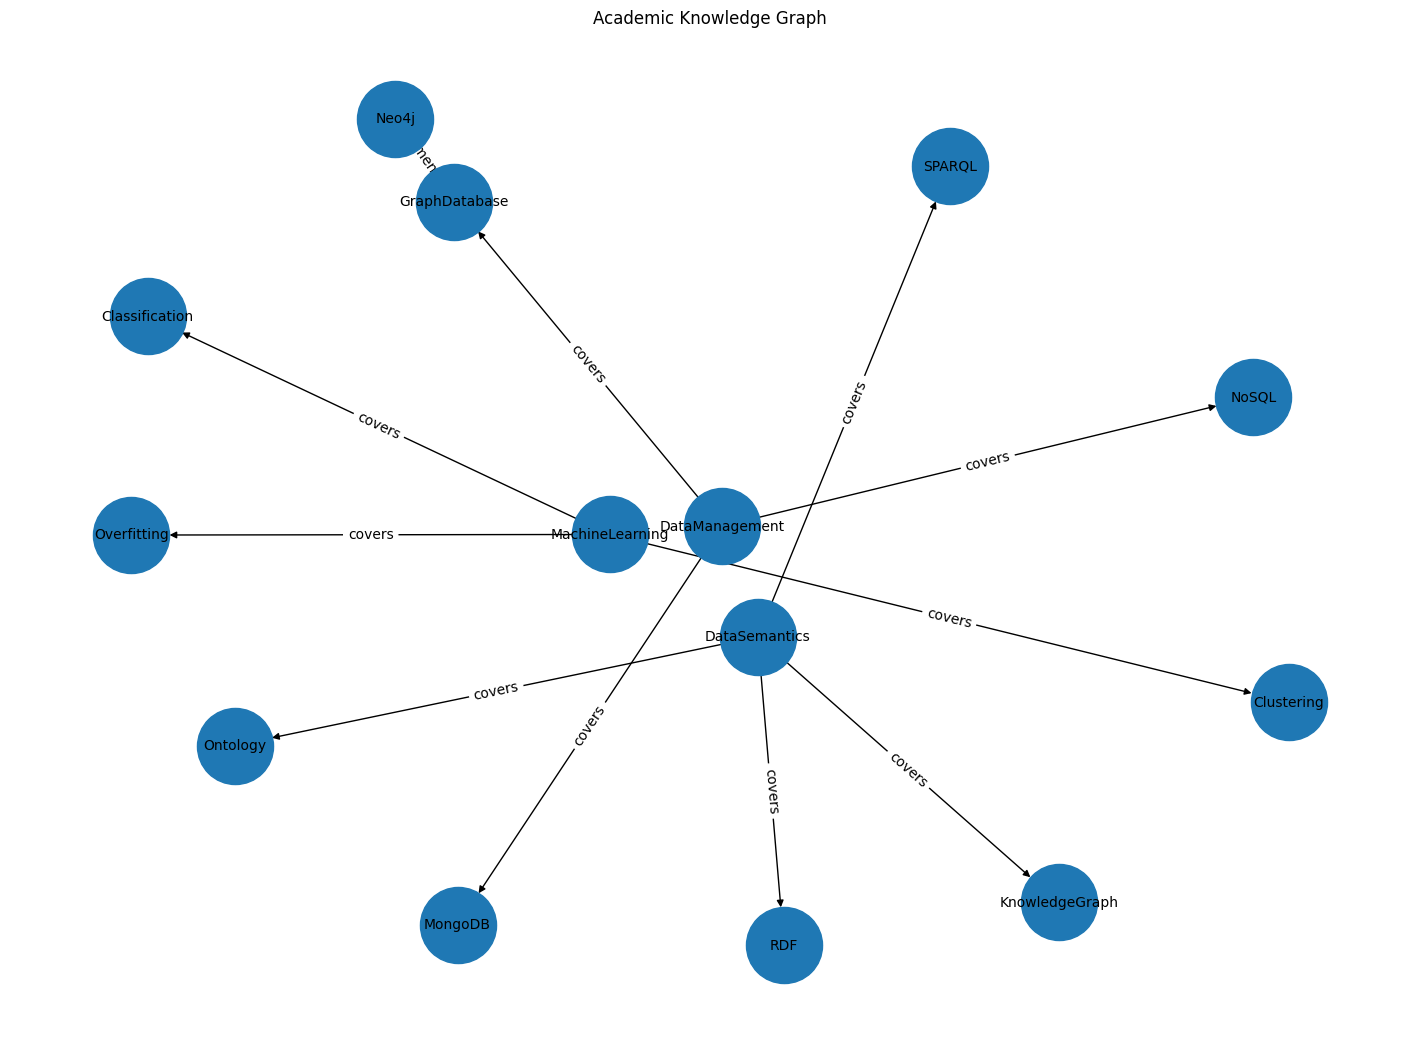

In [15]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=10
)

edge_labels = nx.get_edge_attributes(G, 'label')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Academic Knowledge Graph")

plt.show()